# 01 — Instance Exploration & EDA

**Goal**: Understand the structure of PMSP-SDSC instances before running any experiments.

Topics covered:
1. Instance summary statistics for all 12 configs
2. Setup-cost matrix heatmaps (asymmetric, colour-driven)
3. Processing-time distributions per machine (round-robin assignment proxy)
4. Due-date distributions vs rough completion-time estimates
5. Colour-class breakdown

In [1]:
import sys, os

# Ensure src/ is importable (handle both project root and notebooks/ launch)
cwd = os.getcwd()
if cwd.endswith('/notebooks') or cwd.endswith('\\notebooks'):
    root = os.path.dirname(cwd)
else:
    root = cwd
if root not in sys.path:
    sys.path.insert(0, root)

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from src.instance_generator import generate_instance, INSTANCE_CONFIGS
sns.set_theme(style="whitegrid", palette="muted")
os.makedirs(os.path.join(root, "figures"), exist_ok=True)
SEED = 0

In [2]:
instances = {}
for cfg in INSTANCE_CONFIGS:
    inst = generate_instance(n=cfg["n"], m=cfg["m"], seed=SEED)
    instances[cfg["label"]] = inst
    
print(f"Generated {len(instances)} instances.")
print(list(instances.keys()))

Generated 11 instances.
['tiny_2m', 'small_2m', 'small_3m', 'medium_2m', 'medium_3m', 'medium_30_3m', 'large_2m', 'large_3m', 'large_5m', 'xlarge_5m', 'xlarge_10m']


## 1. Instance Summary Statistics

Key properties: job count, machine count, due-date tightness (fixed at 1.5), mean processing time, mean setup cost (off-diagonal only).

In [3]:
rows = []
for cfg in INSTANCE_CONFIGS:
    lbl = cfg["label"]
    inst = instances[lbl]
    S = inst["setup_cost"]
    # Off-diagonal mask
    mask = ~np.eye(inst["n"], dtype=bool)
    rows.append({
        "Config":           lbl,
        "n_jobs":           inst["n"],
        "n_machines":       inst["m"],
        "Tightness":        1.5,
        "Mean proc. time":  float(np.mean(inst["proc_times"])),
        "Std proc. time":   float(np.std(inst["proc_times"])),
        "Mean setup cost":  float(S[mask].mean()),
        "Max setup cost":   float(S[mask].max()),
        "Mean due date":    float(np.mean(inst["due_dates"])),
    })

summary_df = pd.DataFrame(rows).set_index("Config")
summary_df.round(2)

,n_jobs,n_machines,Tightness,Mean proc. time,Std proc. time,Mean setup cost,Max setup cost,Mean due date
Config,,,,,,,,
tiny_2m,5,2,1.5,10.40,7.91,3.99,8.51,42.59
small_2m,10,2,1.5,22.80,4.28,4.26,14.68,186.49
small_3m,10,3,1.5,22.80,4.28,4.26,14.68,124.33
medium_2m,20,2,1.5,16.15,7.87,4.26,18.60,257.00
medium_3m,20,3,1.5,16.15,7.87,4.26,18.60,171.33
medium_30_3m,30,3,1.5,16.70,7.97,4.41,18.40,267.11
large_2m,50,2,1.5,18.94,6.58,4.43,19.97,760.33
large_3m,50,3,1.5,18.94,6.58,4.43,19.97,506.88
large_5m,50,5,1.5,18.94,6.58,4.43,19.97,304.13


## 2. Setup-Cost Matrix Heatmaps

The matrix is asymmetric: dark-to-light transitions (high `darkness_diff`) incur costs up to `darkness_diff * 10 + noise`. Light-to-dark transitions cost only the uniform noise term ≈ U(0, 2).

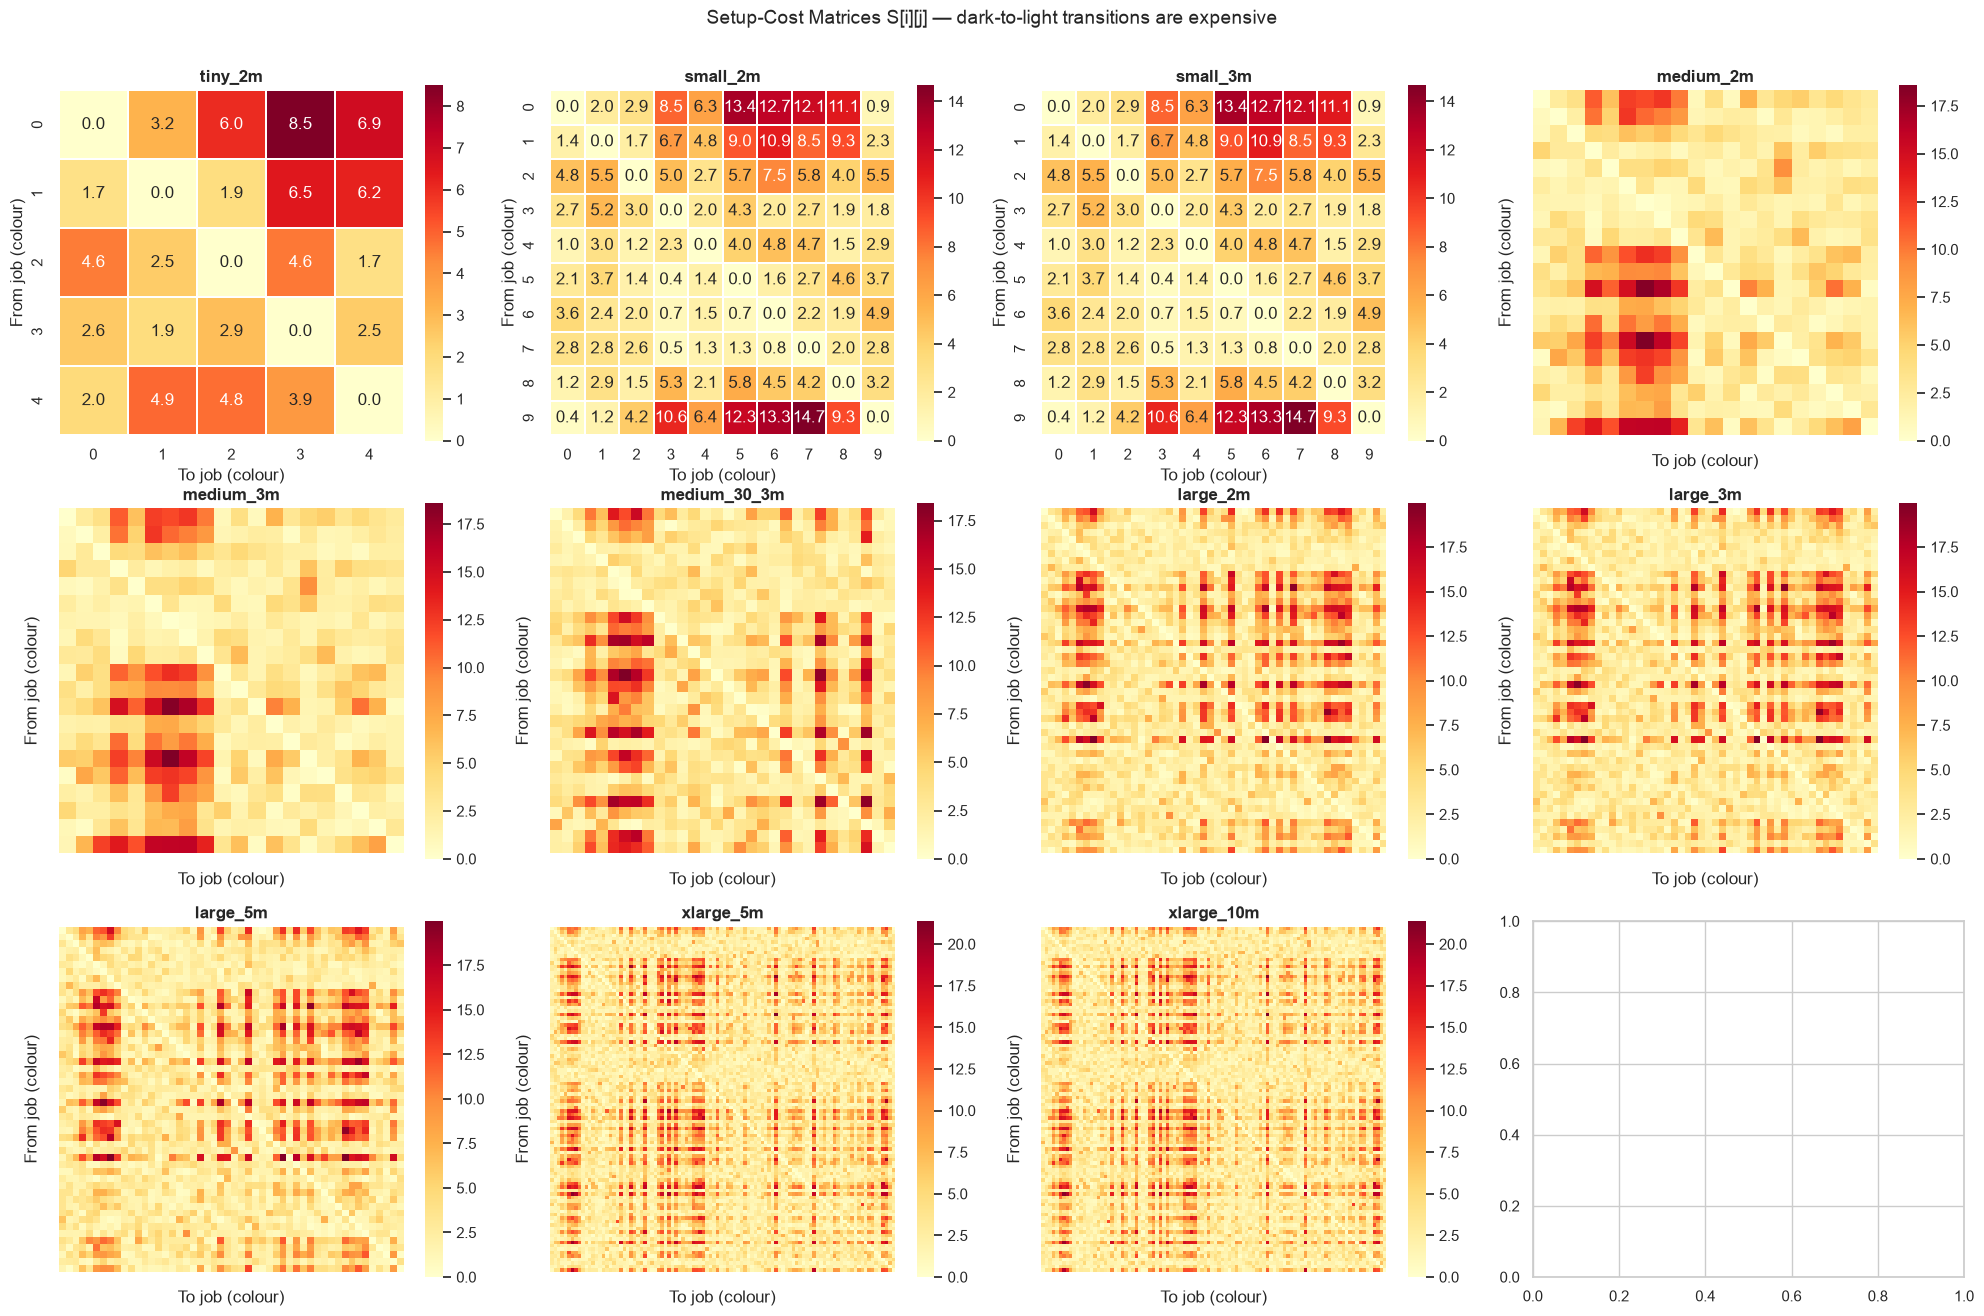

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
axes = axes.flatten()

for ax, cfg in zip(axes, INSTANCE_CONFIGS):
    lbl = cfg["label"]
    inst = instances[lbl]
    S = inst["setup_cost"]
    # Annotate only small instances
    annot = (inst["n"] <= 10)
    sns.heatmap(
        S,
        ax=ax,
        cmap="YlOrRd",
        annot=annot,
        fmt=".1f" if annot else "",
        linewidths=0.3 if annot else 0,
        cbar=True,
        square=True,
    )
    ax.set_title(lbl, fontsize=12, fontweight="bold")
    ax.set_xlabel("To job (colour)")
    ax.set_ylabel("From job (colour)")
    if inst["n"] > 10:
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

fig.suptitle("Setup-Cost Matrices S[i][j] — dark-to-light transitions are expensive",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(root, "figures/01_cost_heatmaps.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. Processing-Time Distributions

Processing times are drawn from `Uniform(5, 31)` (integers). We show distributions split by a naive round-robin machine assignment (SPT order) to approximate per-machine workload imbalance.

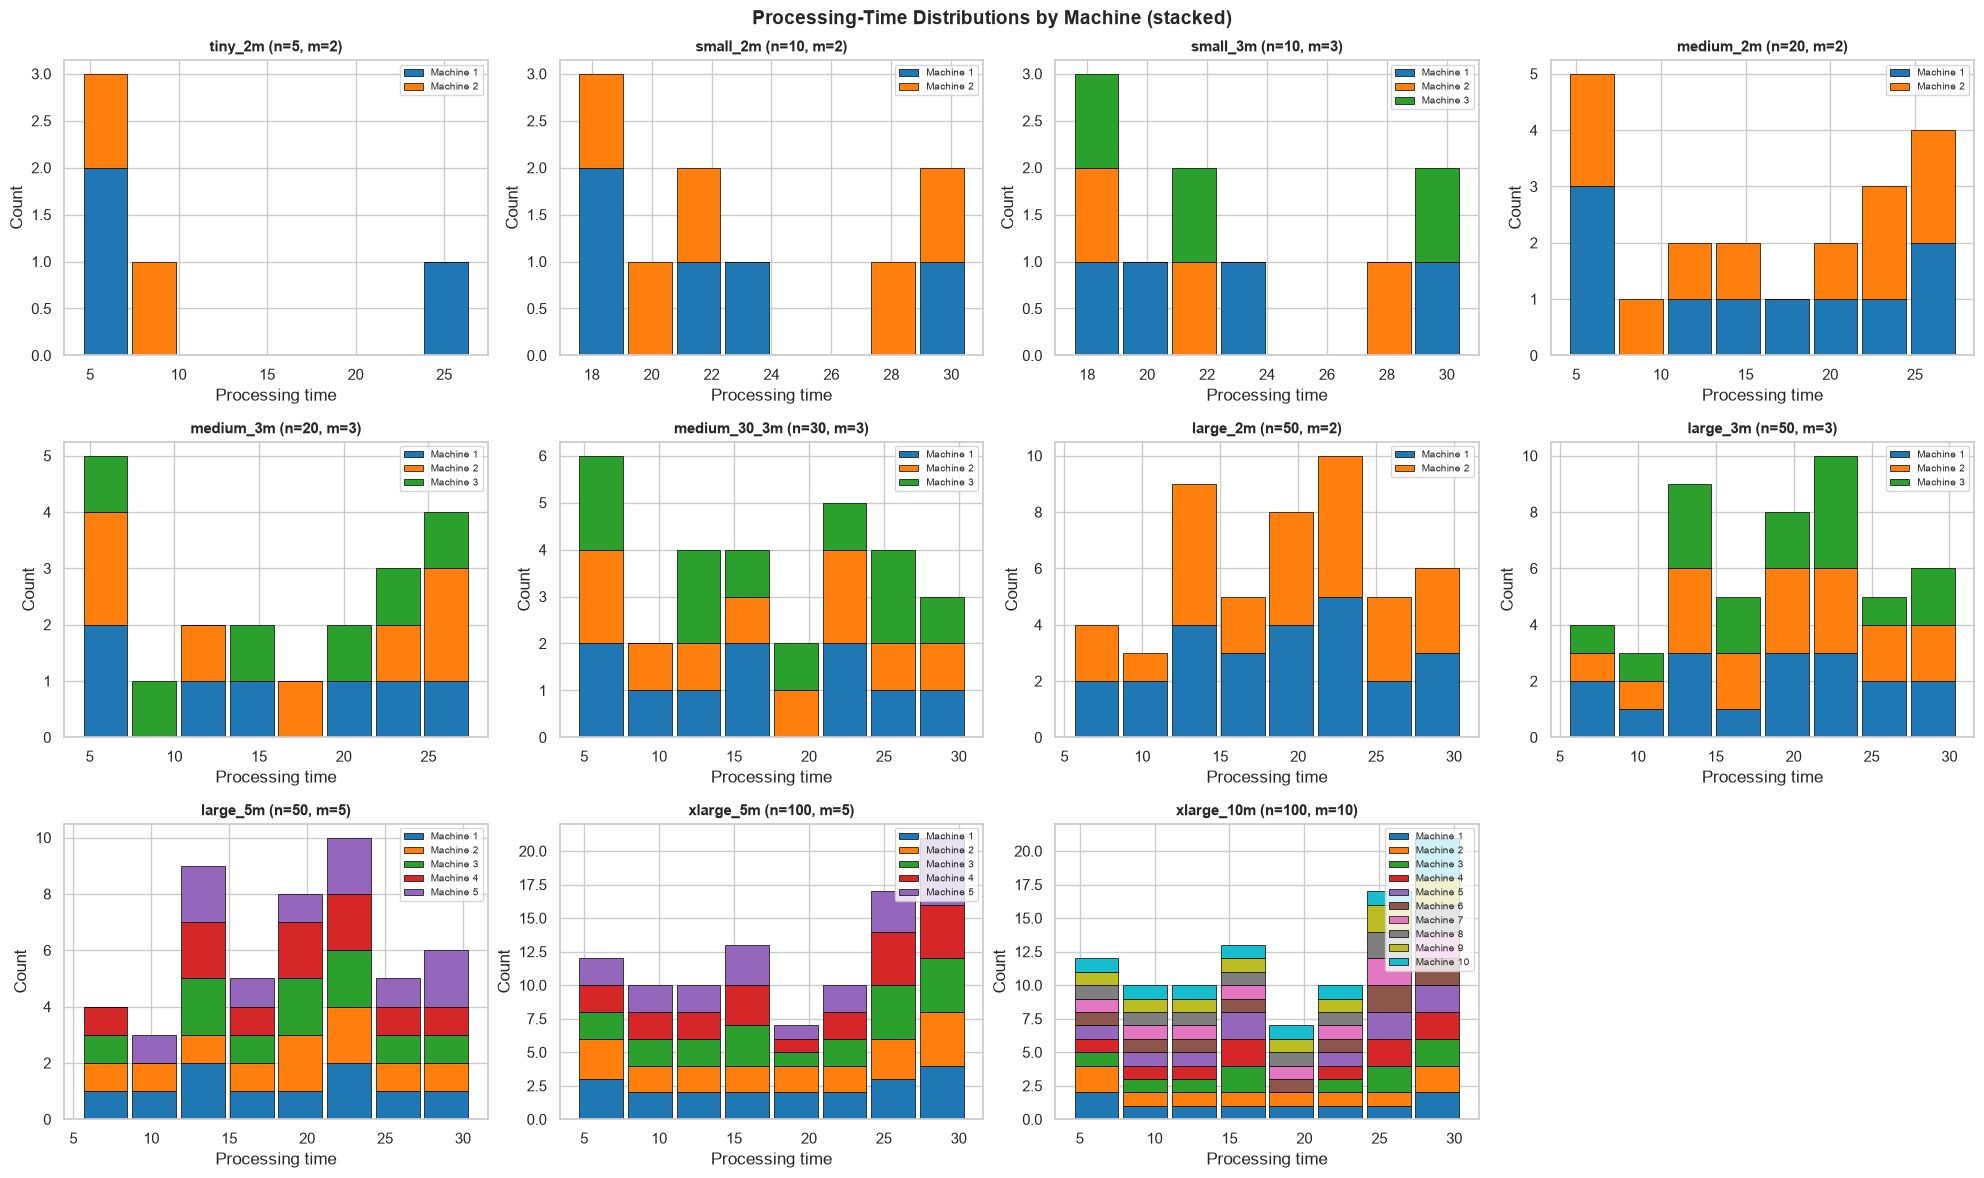

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
N_BINS = 8

for ax, cfg in zip(axes, INSTANCE_CONFIGS):
    lbl = cfg["label"]
    inst = instances[lbl]
    n, m = inst["n"], inst["m"]
    proc = inst["proc_times"]
    order = np.argsort(proc)

    # Collect per-machine processing times
    machine_loads = {k: [] for k in range(m)}
    for i, job in enumerate(order):
        machine_loads[i % m].append(proc[job])

    # Build shared bin edges from all processing times
    all_proc = proc
    bin_edges = np.linspace(all_proc.min() - 0.5, all_proc.max() + 0.5, N_BINS + 1)

    # Compute histograms per machine
    hists = []
    for k in range(m):
        counts, _ = np.histogram(machine_loads[k], bins=bin_edges)
        hists.append(counts)
    hists = np.array(hists)  # shape (m, N_BINS)

    # Plot stacked bars
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]
    bottom = np.zeros(N_BINS)
    colors = sns.color_palette("tab10", m)
    for k in range(m):
        ax.bar(bin_centers, hists[k], width=bin_width * 0.9, bottom=bottom,
               color=colors[k], edgecolor="black", linewidth=0.5, label=f"Machine {k+1}")
        bottom += hists[k]

    ax.set_title(f"{lbl} (n={n}, m={m})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Processing time")
    ax.set_ylabel("Count")
    ax.legend(fontsize=7, loc="upper right")

for ax in axes[len(INSTANCE_CONFIGS):]:
    ax.set_visible(False)

fig.suptitle("Processing-Time Distributions by Machine (stacked)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(root, "figures/01_proc_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Due-Date Distributions vs Completion-Time Estimates

Due dates are generated as:
    `d_i = (p_i / sum(p)) * (sum(p)/m) * tightness * n + noise`

This means d_i is proportional to p_i scaled by total throughput. We compare due dates against a crude estimate of actual completion times assuming sequential single-machine scheduling (worst case).

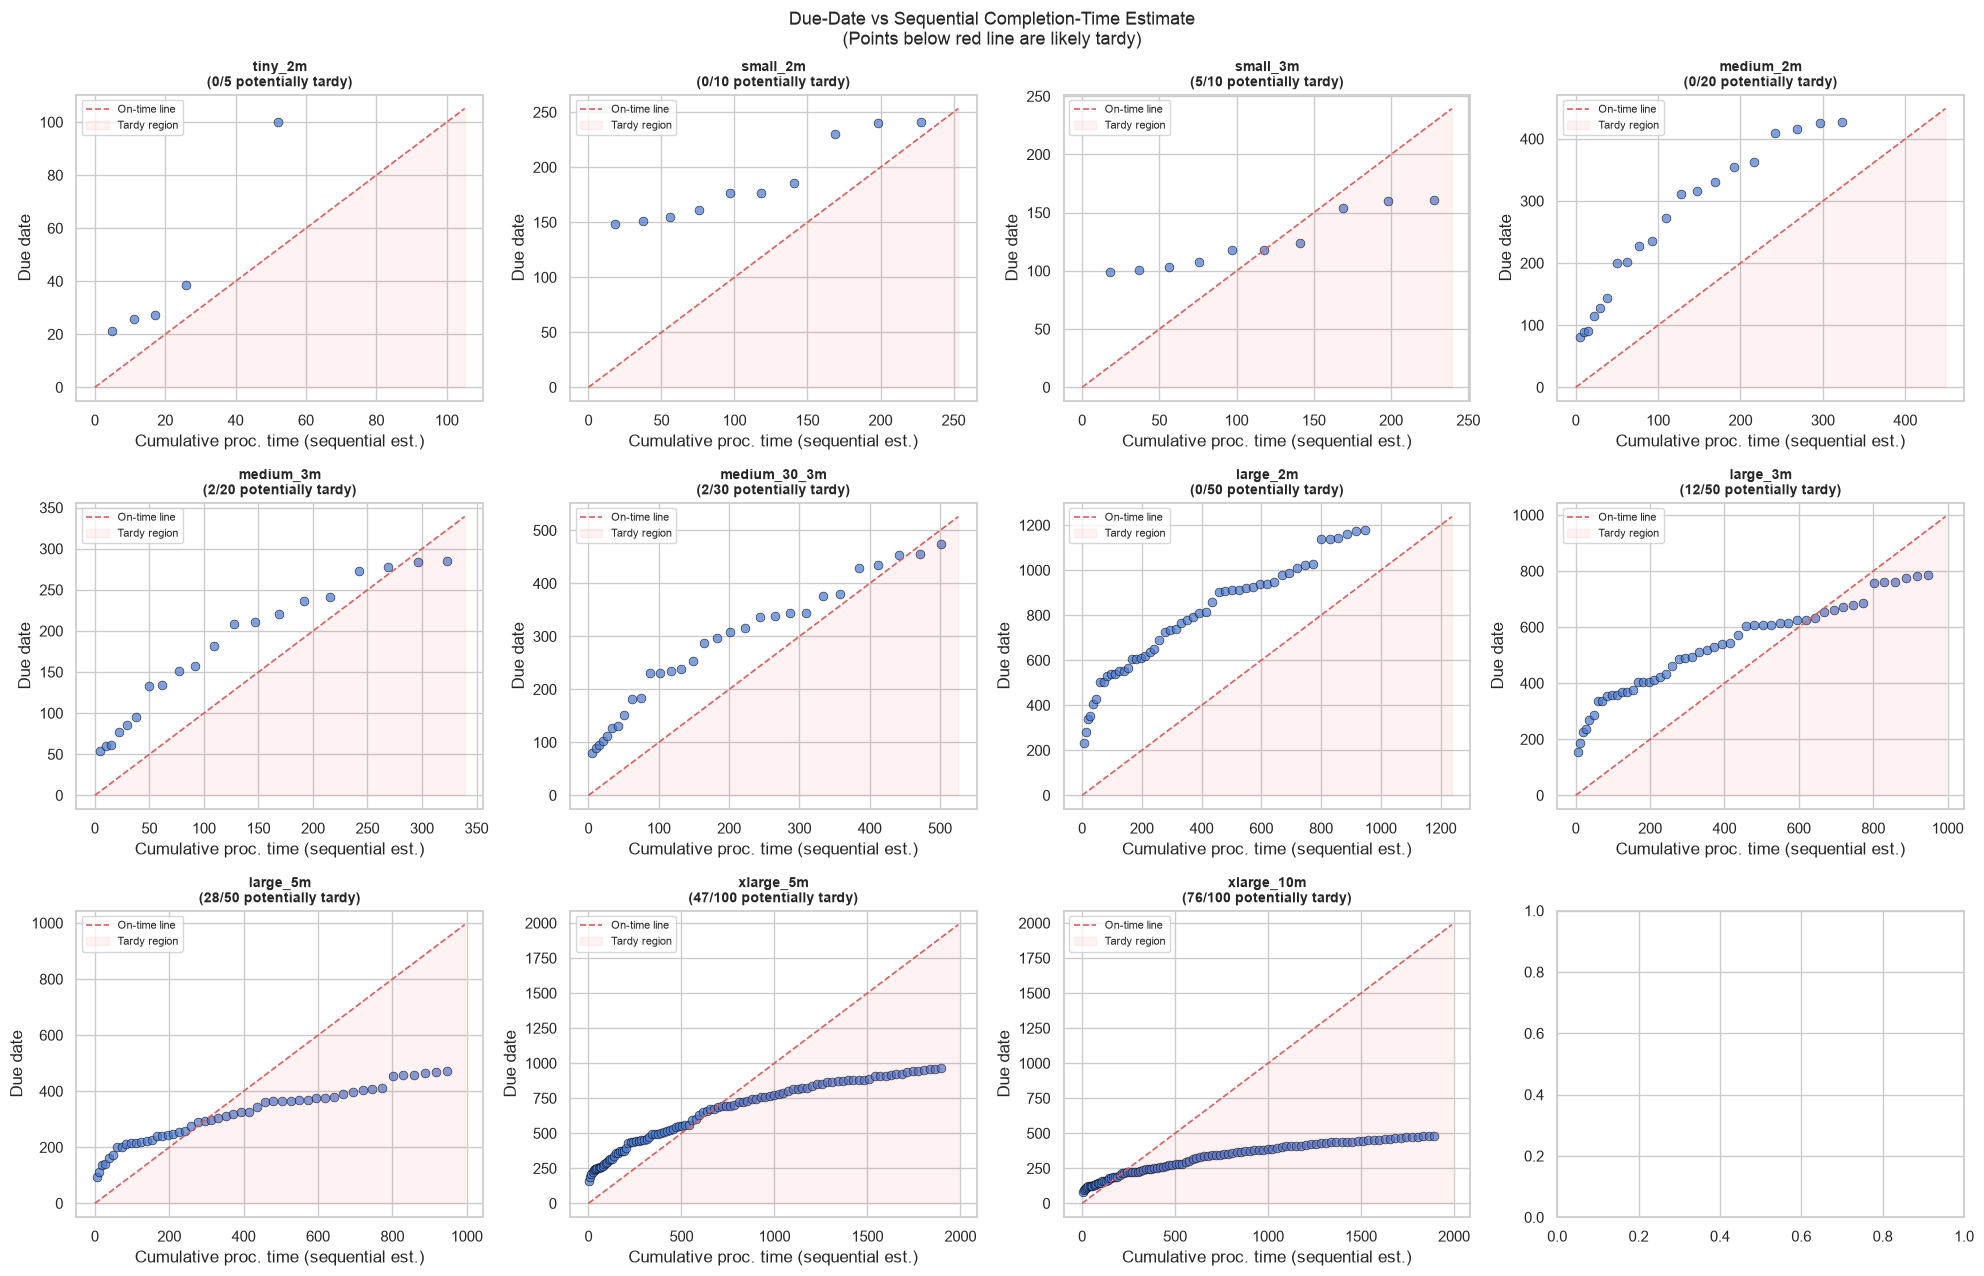

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
axes = axes.flatten()

for ax, cfg in zip(axes, INSTANCE_CONFIGS):
    lbl = cfg["label"]
    inst = instances[lbl]
    
    # Crude sequential estimate: cumulative sum of proc times (no setup, 1 machine)
    proc_sorted = np.sort(inst["proc_times"])
    cumulative = np.cumsum(proc_sorted)
    due_sorted = np.sort(inst["due_dates"])
    
    ax.scatter(cumulative, due_sorted, alpha=0.7, s=40, edgecolors="black", linewidths=0.5)
    # 45-degree reference line
    lim_max = max(cumulative.max(), due_sorted.max()) * 1.05
    ax.plot([0, lim_max], [0, lim_max], "r--", linewidth=1.2, label="On-time line")
    ax.fill_between([0, lim_max], [0, lim_max], [0, 0],
                    alpha=0.05, color="red", label="Tardy region")
    
    n_tardy = int((due_sorted < cumulative).sum())
    ax.set_title(f"{lbl}\n({n_tardy}/{inst['n']} potentially tardy)", fontsize=10, fontweight="bold")
    ax.set_xlabel("Cumulative proc. time (sequential est.)")
    ax.set_ylabel("Due date")
    ax.legend(fontsize=8)

fig.suptitle("Due-Date vs Sequential Completion-Time Estimate\n(Points below red line are likely tardy)",
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(root, "figures/01_duedates_vs_completion.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Colour-Class Distribution

Setup costs are driven by colour transitions. Understanding colour distributions helps predict setup cost magnitudes.

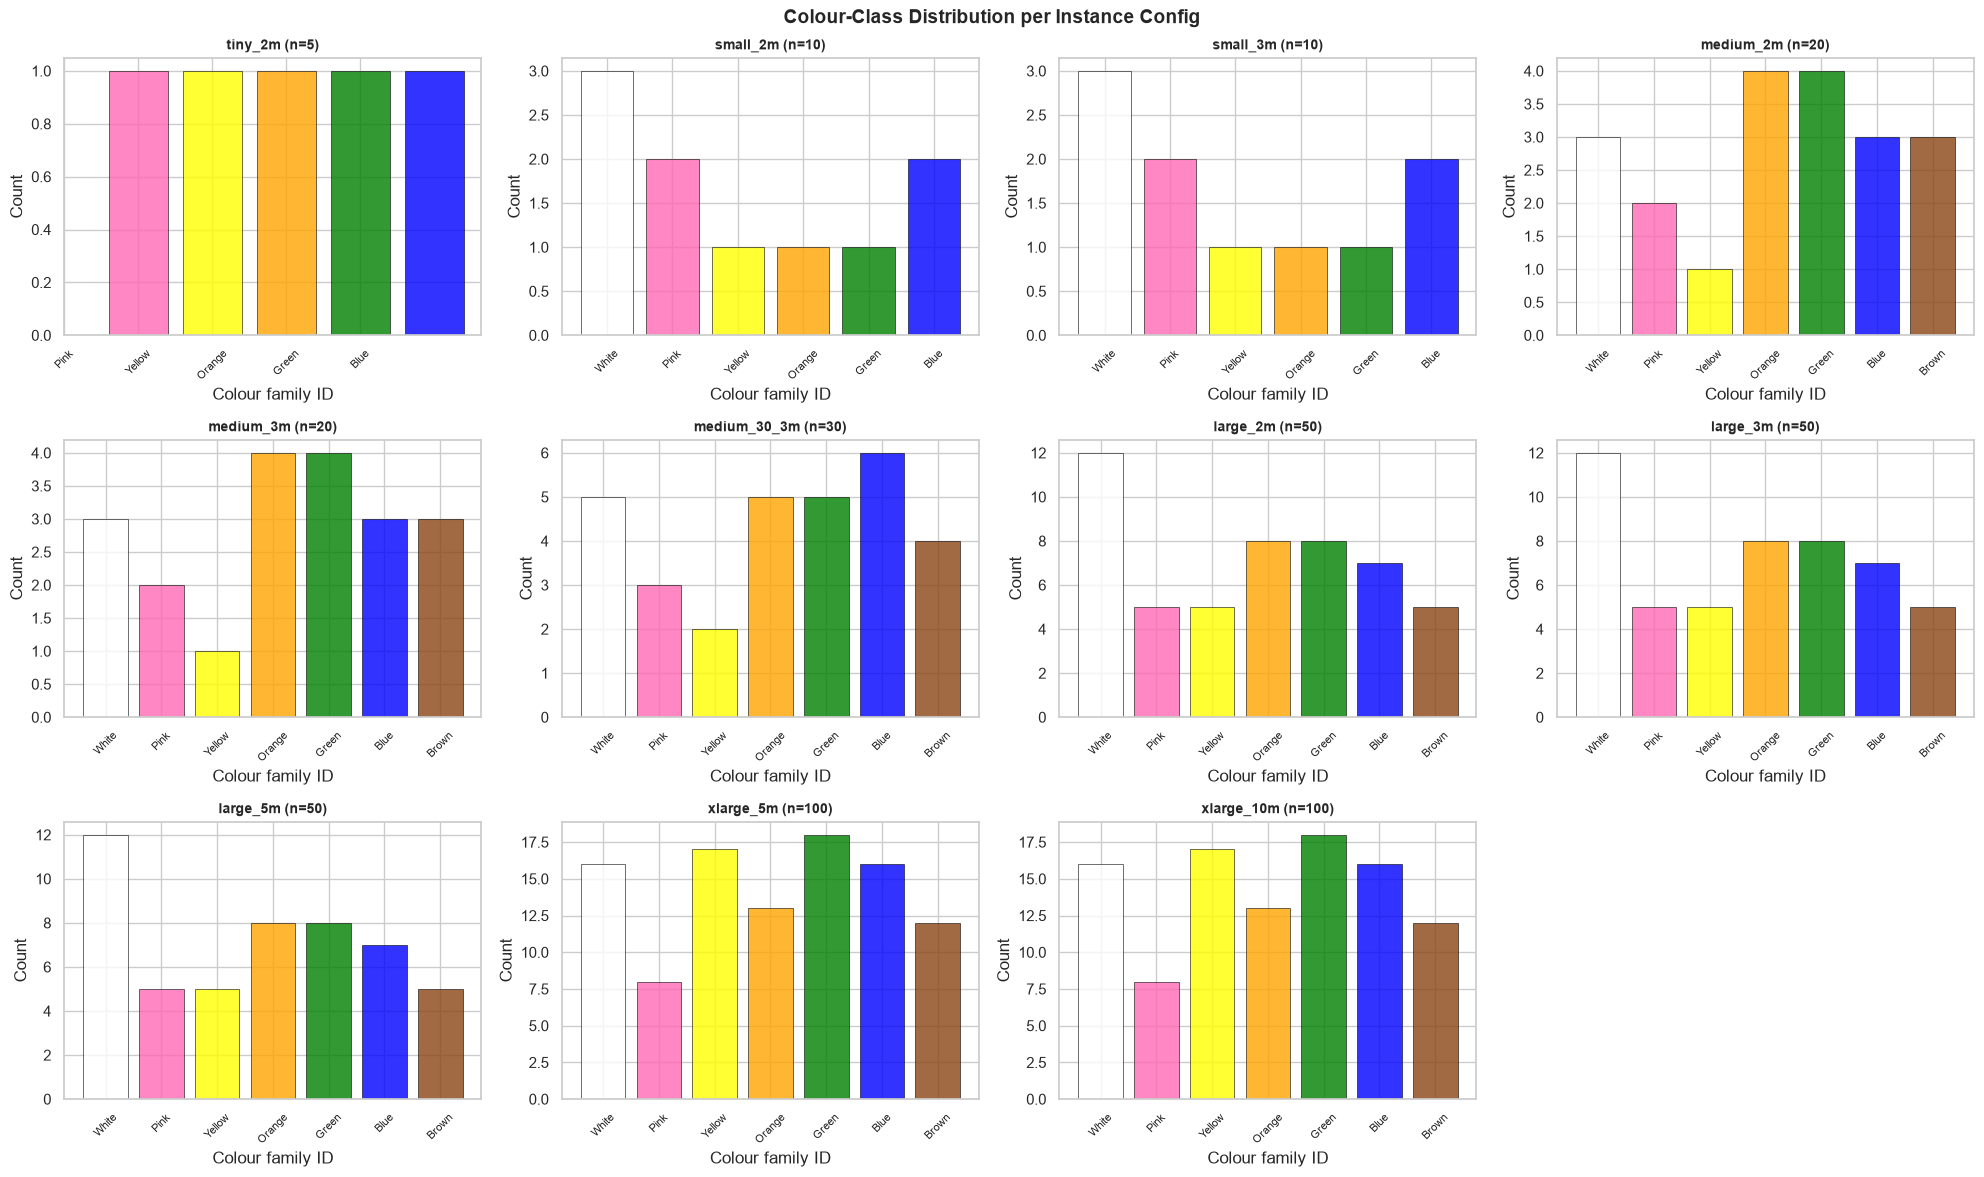

In [7]:
COLOUR_NAMES = {
    0: "White",
    1: "Pink",
    2: "Yellow",
    3: "Orange",
    4: "Green",
    5: "Blue",
    6: "Brown",
    7: "Red",
    8: "Purple",
    9: "Navy",
    10: "Grey",
    11: "Black",
}
COLOUR_HEX = {
    0: "#FFFFFF", 1: "#FF69B4", 2: "#FFFF00", 3: "#FFA500",
    4: "#008000", 5: "#0000FF", 6: "#8B4513", 7: "#FF0000",
    8: "#800080", 9: "#000080", 10: "#808080", 11: "#000000",
}

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
for ax, lbl in zip(axes, instances.keys()):
    inst = instances[lbl]
    colours = inst["colour_ids"]
    unique, counts = np.unique(colours, return_counts=True)
    hex_cols = [COLOUR_HEX.get(int(c), "#999999") for c in unique]
    ax.bar(unique, counts, color=hex_cols, edgecolor="black", linewidth=0.5, alpha=0.8)
    ax.set_title(f"{lbl} (n={inst['n']})", fontsize=10, fontweight="bold")
    ax.set_xlabel("Colour family ID")
    ax.set_ylabel("Count")
    ax.set_xticks(range(len(unique)))
    ax.set_xticklabels([COLOUR_NAMES.get(int(c), str(c)) for c in unique], rotation=45, fontsize=8)
for ax in axes[len(instances):]:
    ax.set_visible(False)
fig.suptitle("Colour-Class Distribution per Instance Config", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(root, "figures/01_colour_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

## Key Takeaways

| Observation | Implication |
|---|---|
| Dark-to-light transitions dominate cost | NN-greedy should outperform SPT on setup cost |
| Due dates proportional to proc times | SPT may accidentally do well on tardiness |
| ~tightness 1.5 gives moderate slack | Both tardiness and setup cost matter |
| Colour distribution is uniform random | Setup cost magnitudes are instance-specific |

These observations motivate the composite objective `F = alpha*f1 + (1-alpha)*f2`.